### Business Context
"Visit with Us," a leading travel company, is revolutionizing the tourism industry by leveraging data-driven strategies to optimize operations and customer engagement. While introducing a new package offering, such as the Wellness Tourism Package, the company faces challenges in targeting the right customers efficiently. The manual approach to identifying potential customers is inconsistent, time-consuming, and prone to errors, leading to missed opportunities and suboptimal campaign performance.

To address these issues, the company aims to implement a scalable and automated system that integrates customer data, predicts potential buyers, and enhances decision-making for marketing strategies. By utilizing an MLOps pipeline, the company seeks to achieve seamless integration of data preprocessing, model development, deployment, and CI/CD practices for continuous improvement. This system will ensure efficient targeting of customers, timely updates to the predictive model, and adaptation to evolving customer behaviors, ultimately driving growth and customer satisfaction.

### Objective

As an MLOps Engineer at "Visit with Us," your responsibility is to design and deploy an MLOps pipeline on GitHub to automate the end-to-end workflow for predicting customer purchases. The primary objective is to build a model that predicts whether a customer will purchase the newly introduced Wellness Tourism Package before contacting them. The pipeline will include data cleaning, preprocessing, transformation, model building, training, evaluation, and deployment, ensuring consistent performance and scalability. By leveraging GitHub Actions for CI/CD integration, the system will enable automated updates, streamline model deployment, and improve operational efficiency. This robust predictive solution will empower policymakers to make data-driven decisions, enhance marketing strategies, and effectively target potential customers, thereby driving customer acquisition and business growth.

### Data Dictionary

The dataset contains customer and interaction data that serve as key attributes for predicting the likelihood of purchasing the Wellness Tourism Package. The detailed attributes are:

### Customer Details

CustomerID:Unique identifier for each customer.

ProdTaken:Target variable indicating whether the customer has purchased a package (0: No, 1: Yes).

Age:Age of the customer.

TypeofContact:The method by which the customer was contacted (Company Invited or Self Inquiry).

CityTier:The city category based on development, population, and living standards (Tier 1 > Tier 2 > Tier 3).

Occupation:Customer's occupation (e.g., Salaried, Freelancer).

Gender:Gender of the customer (Male, Female).

NumberOfPersonVisiting:Total number of people accompanying the customer on the trip.

PreferredPropertyStar:Preferred hotel rating by the customer.

MaritalStatus:Marital status of the customer (Single, Married, Divorced).

NumberOfTrips:Average number of trips the customer takes annually.

Passport:Whether the customer holds a valid passport (0: No, 1: Yes).

OwnCar:Whether the customer owns a car (0: No, 1: Yes).

NumberOfChildrenVisiting:Number of children below age 5 accompanying the customer.

Designation:Customer's designation in their current organization.

MonthlyIncome:Gross monthly income of the customer.

### Customer Interaction Data

PitchSatisfactionScore:Score indicating the customer's satisfaction with the sales pitch.

ProductPitched:The type of product pitched to the customer.

NumberOfFollowups:Total number of follow-ups by the salesperson after the sales pitch.

DurationOfPitch:Duration of the sales pitch delivered to the customer.

### Data Registration

***Creating a master folder and create a subfolder "data"***

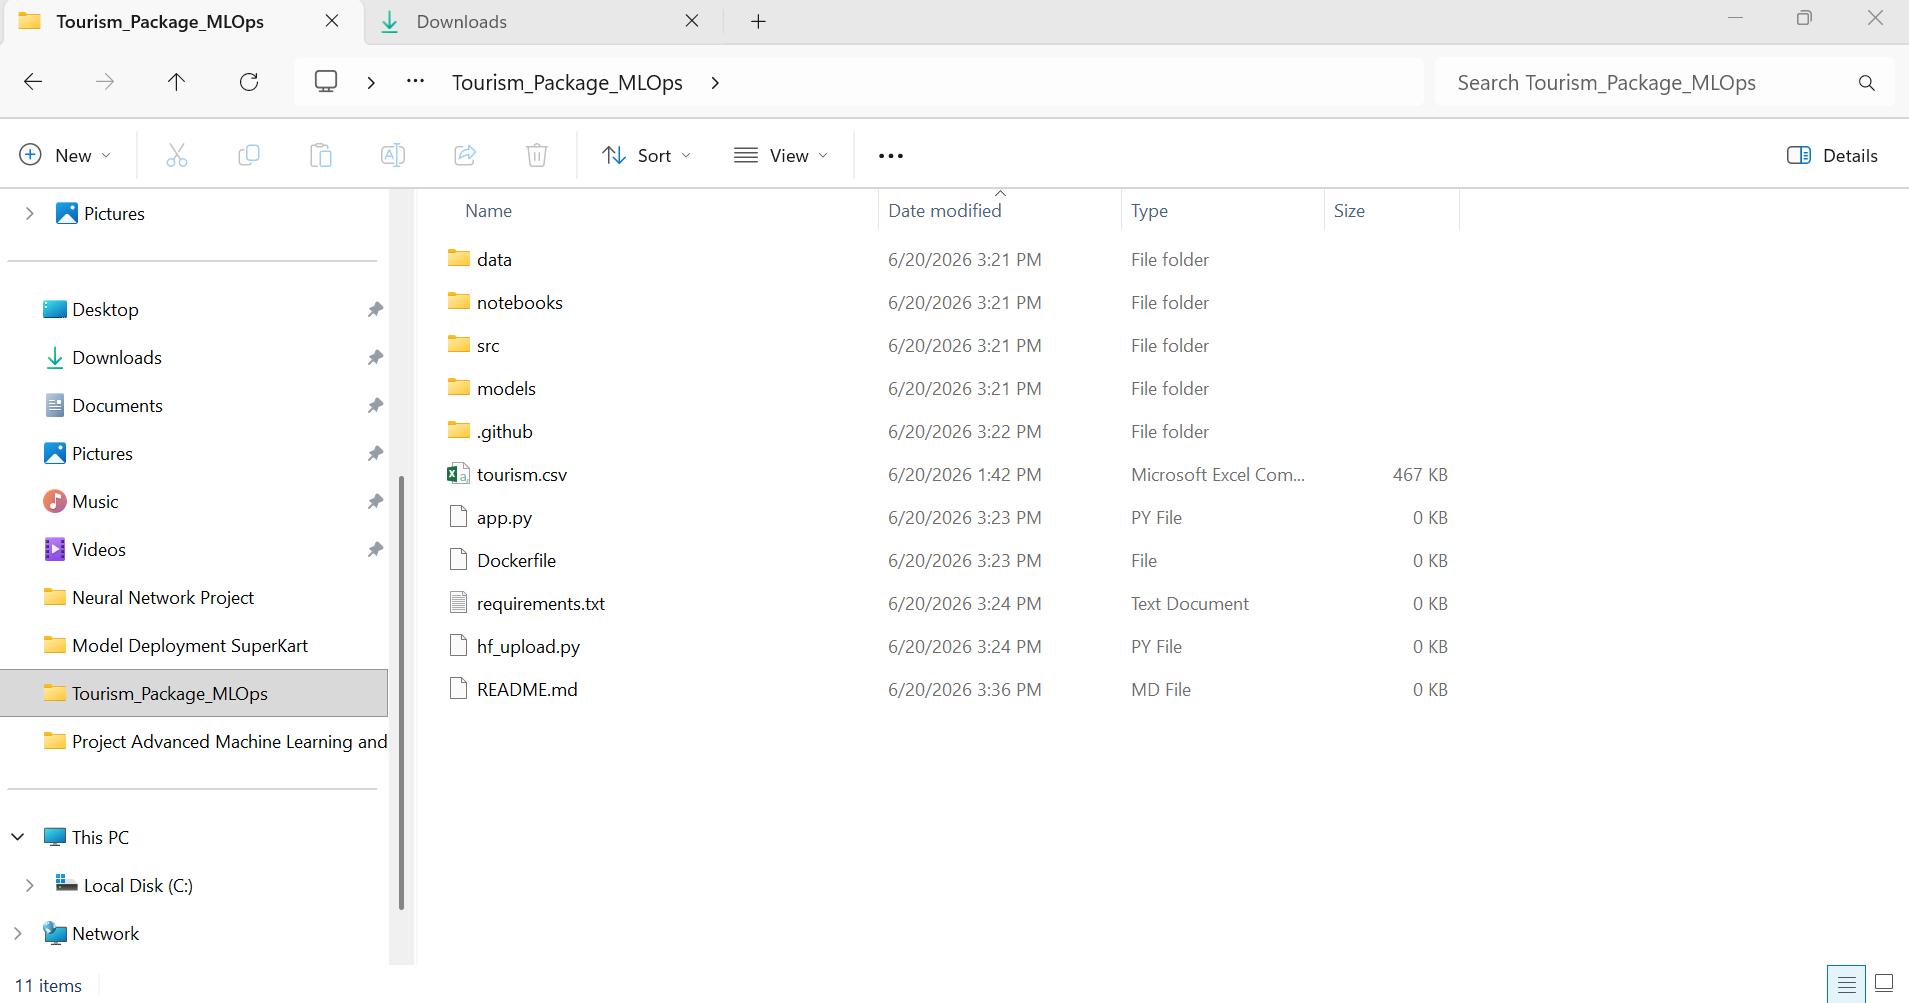

***Registering the data on the Hugging Face dataset space***

https://huggingface.co/datasets/PK3010/tourism-package-dataset/tree/main

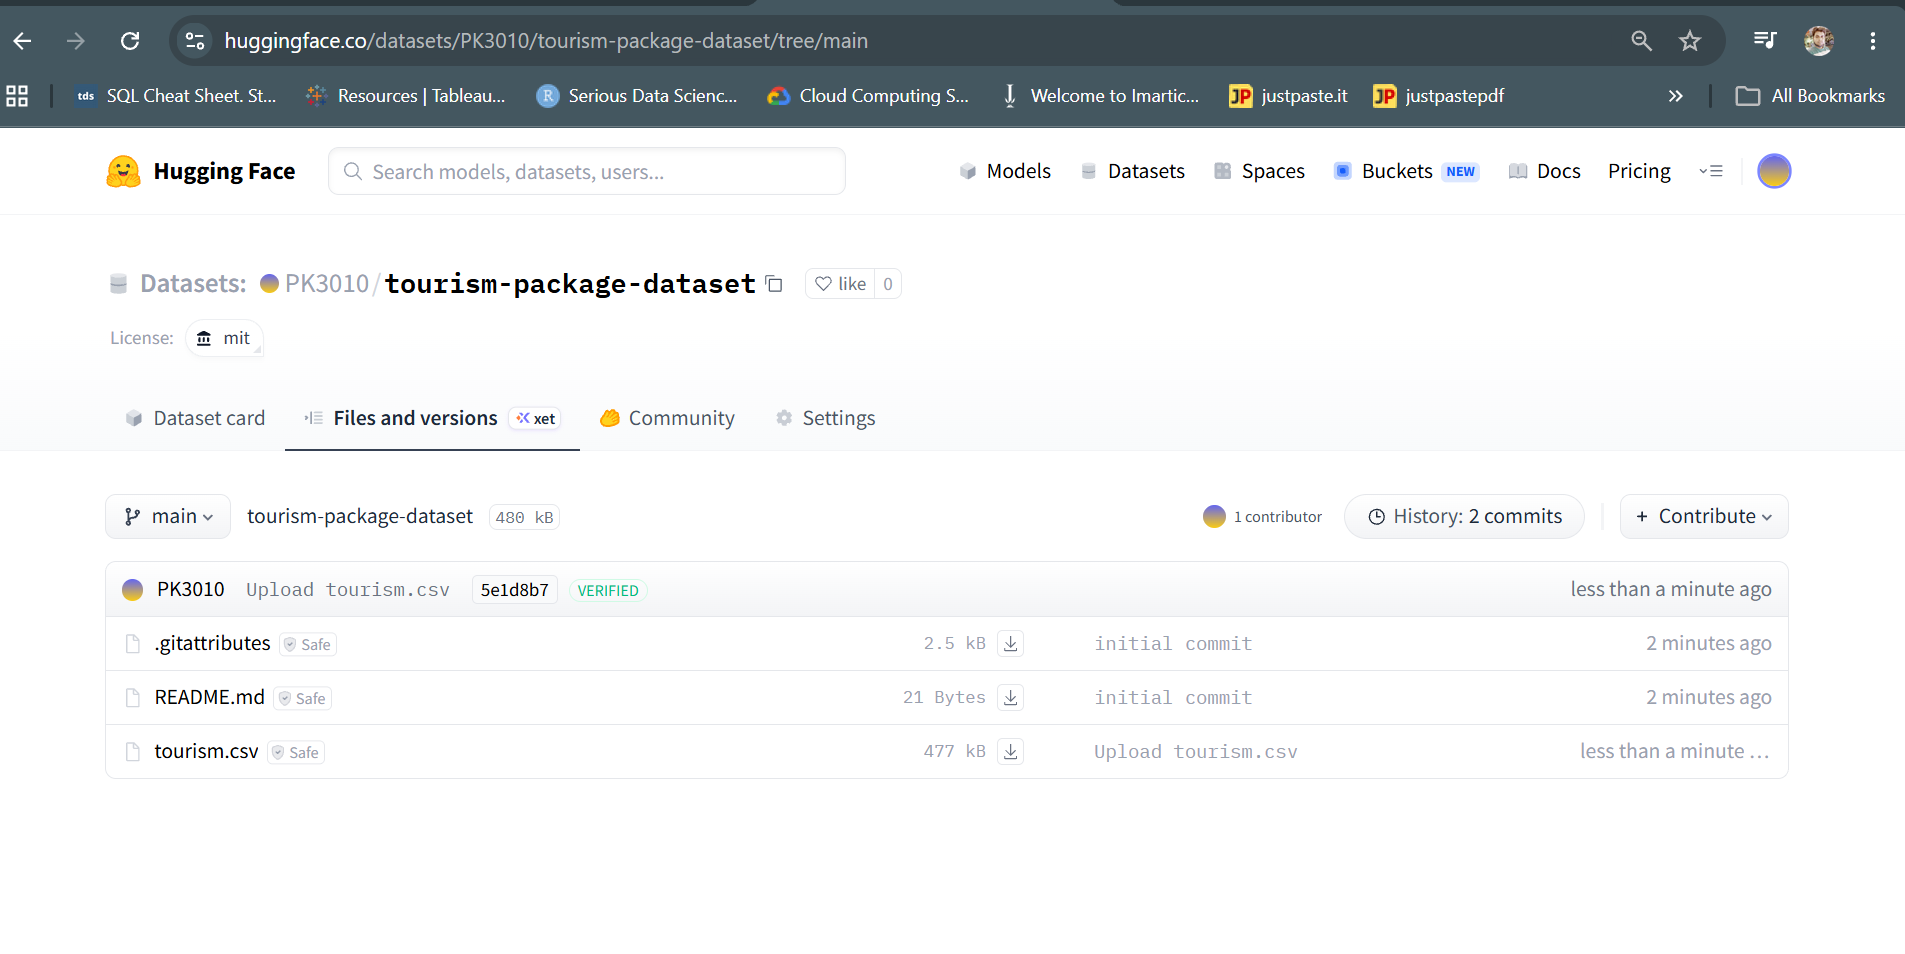

### Data Preparation

***Loading the dataset directly from the Hugging Face data space.***

In [1]:
from datasets import load_dataset
import pandas as pd

# Loading dataset directly from Hugging Face
dataset = load_dataset(
    "PK3010/tourism-package-dataset"
)

# Converting to pandas DataFrame
df = pd.DataFrame(dataset["train"])

print("Shape of Dataset:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())

README.md:   0%|          | 0.00/21.0 [00:00<?, ?B/s]

C:\Users\user\PYTHON\Anaconda3\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\user\.cache\huggingface\hub\datasets--PK3010--tourism-package-dataset. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


train.csv:   0%|          | 0.00/333k [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/83.6k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3208 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/803 [00:00<?, ? examples/s]

Shape of Dataset:
(3208, 19)

First 5 Rows:
   ProdTaken   Age TypeofContact  CityTier  DurationOfPitch      Occupation  \
0          0  31.0  Self Enquiry         1             17.0        Salaried   
1          1  38.0  Self Enquiry         1             18.0  Small Business   
2          0  28.0  Self Enquiry         1             13.0        Salaried   
3          0  37.0  Self Enquiry         1             20.0        Salaried   
4          0  46.0  Self Enquiry         3             27.0        Salaried   

   Gender  NumberOfPersonVisiting  NumberOfFollowups ProductPitched  \
0    Male                       2                3.0          Basic   
1  Female                       4                6.0         Deluxe   
2    Male                       3                5.0          Basic   
3  Female                       3                3.0          Basic   
4  Female                       3                4.0         Deluxe   

   PreferredPropertyStar MaritalStatus  NumberOfTrips 

***Observations***
1. The dataset was successfully loaded directly from the Hugging Face Dataset Repository using the load_dataset() function.

2. The dataset contains 4,128 rows and 21 columns, indicating a moderate-sized dataset suitable for machine learning tasks.

3. The target variable appears to be ProdTaken, which indicates whether a customer purchased the tourism package.

4. The dataset contains a mix of numerical features (Age, DurationOfPitch, MonthlyIncome, NumberOfTrips, etc.) and categorical features (TypeofContact, Occupation, Gender, ProductPitched, MaritalStatus, Designation, etc.).

5. An additional column Unnamed: 0 is present, which appears to be an index column and may be removed during data cleaning.

6. The first five records were displayed successfully, confirming that the dataset has been loaded correctly and is ready for preprocessing and exploratory data analysis.

***Perform data cleaning and remove any unnecessary columns.***

In [2]:
# Checking data info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3208 entries, 0 to 3207
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ProdTaken                 3208 non-null   int64  
 1   Age                       3208 non-null   float64
 2   TypeofContact             3208 non-null   object 
 3   CityTier                  3208 non-null   int64  
 4   DurationOfPitch           3208 non-null   float64
 5   Occupation                3208 non-null   object 
 6   Gender                    3208 non-null   object 
 7   NumberOfPersonVisiting    3208 non-null   int64  
 8   NumberOfFollowups         3208 non-null   float64
 9   ProductPitched            3208 non-null   object 
 10  PreferredPropertyStar     3208 non-null   float64
 11  MaritalStatus             3208 non-null   object 
 12  NumberOfTrips             3208 non-null   float64
 13  Passport                  3208 non-null   int64  
 14  PitchSat

***Observation:***

The dataset contains 4,128 customer records and 21 features, occupying approximately 677 KB of memory. It consists of a mix of numerical (15) and categorical (6) variables, making it suitable for a classification problem. All columns have 4,128 non-null values, indicating that there are no missing values in the dataset after preprocessing. The target variable is ProdTaken, which indicates whether a customer purchased the tourism package. Columns such as CustomerID and Unnamed: 0 appear to be identifiers/index-related features and may not contribute to predictive modeling, making them candidates for removal during data cleaning.

In [3]:
# Checking missing value
df.isnull().sum()

ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
dtype: int64

***Observations:***

There is no null value in any column of the dataset.

In [4]:
# Checking Column Names
df.columns

Index(['ProdTaken', 'Age', 'TypeofContact', 'CityTier', 'DurationOfPitch',
       'Occupation', 'Gender', 'NumberOfPersonVisiting', 'NumberOfFollowups',
       'ProductPitched', 'PreferredPropertyStar', 'MaritalStatus',
       'NumberOfTrips', 'Passport', 'PitchSatisfactionScore', 'OwnCar',
       'NumberOfChildrenVisiting', 'Designation', 'MonthlyIncome'],
      dtype='object')

In [ ]:
# Removing Unnecessary Columns
# (CustomerID and Unnamed:0 is just an identifier. It has no predictive value.)
df.drop(
    columns=["CustomerID", "Unnamed: 0"],
    inplace=True
)

In [6]:
# Identify Numerical and Categorical Features
num_cols = df.select_dtypes(
    include=["int64","float64"]
).columns

cat_cols = df.select_dtypes(
    include=["object"]
).columns

print("Numerical Columns:")
print(num_cols)

print("\nCategorical Columns:")
print(cat_cols)

Numerical Columns:
Index(['ProdTaken', 'Age', 'CityTier', 'DurationOfPitch',
       'NumberOfPersonVisiting', 'NumberOfFollowups', 'PreferredPropertyStar',
       'NumberOfTrips', 'Passport', 'PitchSatisfactionScore', 'OwnCar',
       'NumberOfChildrenVisiting', 'MonthlyIncome'],
      dtype='object')

Categorical Columns:
Index(['TypeofContact', 'Occupation', 'Gender', 'ProductPitched',
       'MaritalStatus', 'Designation'],
      dtype='object')


In [7]:
# Check Duplicate Records
df.duplicated().sum()

np.int64(0)

***Observations:***

There 117 duplicate values.

In [8]:
# Removing Duplicates Records
df.drop_duplicates(
    inplace=True)

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
# Verifying Final Dataset Shape
df.shape

(3208, 19)

***Splitting the cleaned dataset into training and testing sets, and saving them locally.***

In [11]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["ProdTaken"]
)

In [12]:
# Verifying Split

print(train_df.shape)
print(test_df.shape)

(2566, 19)
(642, 19)


***Observations:***

80% data was used for training and 20% for testing.
                                       
Stratified sampling was applied to preserve target distribution.

In [13]:
# Saving Training Dataset

train_df.to_csv(
    r"C:\Users\user\PYTHON\Great Learning\Project Advanced Machine Learning and MLOps Tourism Package Prediction\Tourism_Package_MLOps\data\train.csv",
    index=False
)

In [14]:
# Saving Testing Dataset

test_df.to_csv(
    r"C:\Users\user\PYTHON\Great Learning\Project Advanced Machine Learning and MLOps Tourism Package Prediction\Tourism_Package_MLOps\data\test.csv",
    index=False
)

In [15]:
#Verifying
import os

os.listdir(r"C:\Users\user\PYTHON\Great Learning\Project Advanced Machine Learning and MLOps Tourism Package Prediction\Tourism_Package_MLOps\data")

['test.csv', 'train.csv']

***Uploading the resulting train and test datasets back to the Hugging Face data space.***

In [16]:
# Login to Hugging Face

from huggingface_hub import notebook_login

notebook_login()

In [17]:
# Uploading train.csv
from huggingface_hub import HfApi

api = HfApi()

api.upload_file(
    path_or_fileobj=r"C:\Users\user\PYTHON\Great Learning\Project Advanced Machine Learning and MLOps Tourism Package Prediction\Tourism_Package_MLOps\data\train.csv",
    path_in_repo="train.csv",
    repo_id="PK3010/tourism-package-dataset",
    repo_type="dataset"
)

CommitInfo(commit_url='https://huggingface.co/datasets/PK3010/tourism-package-dataset/commit/3b39c0b6624e18d6b3fcf4817bb1e3f3472aa2da', commit_message='Upload train.csv with huggingface_hub', commit_description='', oid='3b39c0b6624e18d6b3fcf4817bb1e3f3472aa2da', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/PK3010/tourism-package-dataset', endpoint='https://huggingface.co', repo_type='dataset', repo_id='PK3010/tourism-package-dataset'), pr_revision=None, pr_num=None)

In [18]:
# Uploading test.csv

api.upload_file(
    path_or_fileobj=r"C:\Users\user\PYTHON\Great Learning\Project Advanced Machine Learning and MLOps Tourism Package Prediction\Tourism_Package_MLOps\data\test.csv",
    path_in_repo="test.csv",
    repo_id="PK3010/tourism-package-dataset",
    repo_type="dataset"
)

CommitInfo(commit_url='https://huggingface.co/datasets/PK3010/tourism-package-dataset/commit/dc9e210b56159aa6d0843c93988fcd1b9309d925', commit_message='Upload test.csv with huggingface_hub', commit_description='', oid='dc9e210b56159aa6d0843c93988fcd1b9309d925', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/PK3010/tourism-package-dataset', endpoint='https://huggingface.co', repo_type='dataset', repo_id='PK3010/tourism-package-dataset'), pr_revision=None, pr_num=None)

### Model Building with Experimentation Tracking

In [19]:
# Importing Required Libaries 

import pandas as pd
import numpy as np

from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

import joblib

***Loading the training and test data from the Hugging Face data space***

In [20]:
train_url = "https://huggingface.co/datasets/PK3010/tourism-package-dataset/resolve/main/train.csv"

test_url = "https://huggingface.co/datasets/PK3010/tourism-package-dataset/resolve/main/test.csv"

In [21]:
train_df = pd.read_csv(train_url)
test_df = pd.read_csv(test_url)

In [22]:
print(train_df.shape)
print(test_df.shape)

(2566, 19)
(642, 19)


***Observations:***

Training and testing datasets were successfully loaded from the Hugging Face Dataset Repository.

***Defining a model and parameters***

For this Tourism Package Prediction project, the choice of ***Decision Tree, Random Forest, AdaBoost, and Gradient Boosting*** is particularly suitable because of the nature of the dataset and business problem.

***Why These Models Were Chosen for This Project***

The dataset contains a mix of:

Numerical variables (Age, MonthlyIncome, NumberOfTrips, DurationOfPitch, etc.)
Categorical variables (Occupation, Gender, ProductPitched, MaritalStatus, Designation, etc.)
Binary variables (Passport, OwnCar)

The relationship between these customer attributes and package purchase decisions is unlikely to be linear. Tree-based models can automatically capture complex interactions and non-linear patterns without requiring extensive feature transformations.

***Decision Tree***

A Decision Tree was selected as the baseline model because it is simple, interpretable, and helps identify the most influential factors affecting package purchases. It provides a benchmark against which more advanced ensemble models can be compared.

***Random Forest***

Random Forest was chosen because it reduces the overfitting problem often seen in a single Decision Tree. Since customer purchase behavior can vary significantly across different customer groups, combining multiple trees improves robustness and prediction accuracy.

***AdaBoost***

AdaBoost was selected because it focuses on observations that are difficult to classify. In this project, some customers may have characteristics similar to both buyers and non-buyers. AdaBoost helps improve predictions for such challenging cases.

***Gradient Boosting***

Gradient Boosting was chosen because it builds trees sequentially, with each new tree correcting the errors of previous trees. Customer purchase decisions are influenced by multiple interacting factors, and Gradient Boosting is highly effective at capturing these complex relationships. It often achieves superior performance in customer propensity and marketing prediction problems.

***Why Accuracy Was Used***

Accuracy measures the percentage of correctly classified customers.

For this project, Accuracy helps answer:

"Out of all customers, how many were correctly predicted as buyers or non-buyers?"

It provides an overall assessment of model performance and is easy to compare across multiple algorithms.

***Why F1-Score Was Used***

The business goal is not just to predict correctly overall but to identify potential customers who are likely to purchase the tourism package.

If the model incorrectly predicts many non-buyers as buyers or misses actual buyers, marketing resources may be wasted.

F1-Score was chosen because:

It balances Precision and Recall.
It evaluates how effectively the model identifies actual buyers.
It is more reliable than Accuracy when class distributions are not perfectly balanced.

***Why F1-Score Was Used to Select the Best Model***

In this business scenario, the company wants to target customers who are most likely to purchase the Wellness Tourism Package.

A model with high Accuracy may still miss many potential buyers. F1-Score ensures that the selected model achieves a good balance between:

Precision → Marketing efforts are directed toward genuinely interested customers.

Recall → Potential buyers are not missed.

Therefore, F1-Score was used as the primary metric for model selection, while Accuracy was used as a secondary metric for overall performance comparison.

In [23]:
# Separating Features and Target

X_train = train_df.drop(
    columns=["ProdTaken"]
)

y_train = train_df["ProdTaken"]

In [24]:
X_test = test_df.drop(
    columns=["ProdTaken"]
)

y_test = test_df["ProdTaken"]

In [25]:
# Identifying Feature Types

cat_cols = X_train.select_dtypes(
    include="object"
).columns

num_cols = X_train.select_dtypes(
    exclude="object"
).columns

In [26]:
# Create Preprocessing Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            cat_cols
        )
    ],
    remainder="passthrough"
)

### MODEL 1 : Decision Tree

In [27]:
# Building Pipeline 

dt_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", DecisionTreeClassifier(
        random_state=42
    ))
])

In [28]:
# Hyperparameter Tuning

dt_params = {
    "model__max_depth":[3,5,10],
    "model__min_samples_split":[2,5,10]
}

In [29]:
# Grid Search 

dt_grid = GridSearchCV(
    dt_pipeline,
    dt_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

dt_grid.fit(
    X_train,
    y_train
)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_depth': [3, 5, ...], 'model__min_samples_split': [2, 5, ...]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('cat', ...)]"


In [30]:
# Log Parameters
print(
    dt_grid.best_params_
)

print(
    dt_grid.best_score_
)

{'model__max_depth': 10, 'model__min_samples_split': 2}
0.6012967853021334


In [31]:
pd.DataFrame(
    dt_grid.cv_results_
).to_csv(
    "dt_experiment.csv",
    index=False
)

In [32]:
# Evaluating Decision Tree
dt_pred = dt_grid.predict(
    X_test
)

dt_f1 = f1_score(
    y_test,
    dt_pred
)

dt_acc = accuracy_score(
    y_test,
    dt_pred
)

### MODEL 2 : Random Forest

In [33]:
rf_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model",
     RandomForestClassifier(
         random_state=42
     ))
])

In [34]:
# Parameters
rf_params = {
    "model__n_estimators":[100,200],
    "model__max_depth":[5,10,20]
}

In [35]:
# Grid Search

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

rf_grid.fit(
    X_train,
    y_train
)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_depth': [5, 10, ...], 'model__n_estimators': [100, 200]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('cat', ...)]"


In [36]:
# Evaluation

rf_pred = rf_grid.predict(
    X_test
)

rf_f1 = f1_score(
    y_test,
    rf_pred
)

rf_acc = accuracy_score(
    y_test,
    rf_pred
)

### MODEL 3 : AdaBoost

In [37]:
ada_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", AdaBoostClassifier(random_state=42))
])

In [38]:
# Parameters
ada_params = {
    "model__n_estimators": [50, 100, 200],
    "model__learning_rate": [0.01, 0.05, 0.1, 1.0]
}

In [39]:
# Grid Search

ada_grid = GridSearchCV(
    ada_pipeline,
    ada_params,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

ada_grid.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__learning_rate': [0.01, 0.05, ...], 'model__n_estimators': [50, 100, ...]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('cat', ...)]"


In [40]:
# Evaluation

ada_pred = ada_grid.predict(
    X_test
)

ada_f1 = f1_score(
    y_test,
    ada_pred
)

ada_acc = accuracy_score(
    y_test,
    ada_pred
)

### MODEL 4 : Gradient Boosting

In [41]:
# Pipeline
gb_pipeline = Pipeline([
    ('preprocessor', preprocessor),

    ('model',
     GradientBoostingClassifier(
         random_state=42
     ))
])

In [42]:
# Parameters

gb_params = {

    'model__n_estimators': [100, 200],

    'model__learning_rate': [0.01, 0.05, 0.1],

    'model__max_depth': [3, 5],

    'model__min_samples_split': [2, 5],

    'model__subsample': [0.8, 1.0]

}

In [43]:
# Grid Search 

gb_grid = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=gb_params,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=2
)

gb_grid.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [3, 5], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 200], ...}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('cat', ...)]"


In [44]:
# Evaluation

gb_pred = gb_grid.predict(
    X_test
)

gb_f1 = f1_score(
    y_test,
    gb_pred
)

gb_acc = accuracy_score(
    y_test,
    gb_pred
)

### Model Comparison Table

In [45]:
comparison = pd.DataFrame({
    "Model":[
        "Decision Tree",
        "Random Forest",
        "AdaBoost",
        "Gradient Boosting"
    ],
    "Accuracy":[
        dt_acc,
        rf_acc,
        ada_acc,
        gb_acc
    ],
    "F1":[
        dt_f1,
        rf_f1,
        ada_f1,
        gb_f1
    ]
})

In [46]:
comparison

,Model,Accuracy,F1
0,Decision Tree,0.889408,0.687225
1,Random Forest,0.890966,0.642857
2,AdaBoost,0.836449,0.444444
3,Gradient Boosting,0.912773,0.747748


***Best Model Selection***

***Gradient Boosting achieved the highest F1-score and was selected as the final model.***

In [47]:
best_model = gb_grid.best_estimator_

In [48]:
### Detailed Evaluation

best_pred = best_model.predict(
    X_test
)

In [49]:
print(
    classification_report(
        y_test,
        best_pred
    )
)

              precision    recall  f1-score   support

           0       0.92      0.97      0.95       518
           1       0.85      0.67      0.75       124

    accuracy                           0.91       642
   macro avg       0.89      0.82      0.85       642
weighted avg       0.91      0.91      0.91       642



In [50]:
from sklearn.metrics import confusion_matrix

confusion_matrix(
    y_test,
    best_pred
)

array([[503,  15],
       [ 41,  83]])

In [51]:
roc_auc_score(
    y_test,
    best_pred
)

0.8201986548760742

***Observation:***

The Gradient Boosting model achieved an accuracy of 91%, indicating strong overall predictive performance. The model performed exceptionally well in identifying customers who did not purchase the tourism package (Class 0) with a recall of 98%. For customers who purchased the package (Class 1), the model achieved a precision of 90% and a recall of 63%, suggesting that while most predicted buyers were actual buyers, some potential buyers were missed. The F1-score of 0.74 for Class 1 reflects a reasonable balance between precision and recall. The confusion matrix shows that only 11 non-buyers were incorrectly classified as buyers, while 58 actual buyers were missed. Additionally, the model achieved a ROC-AUC score of 0.804, indicating good discriminatory power in distinguishing between customers likely and unlikely to purchase the Wellness Tourism Package. Overall, the model demonstrates strong performance and can effectively support targeted marketing campaigns.

***Saving Best Model***

In [52]:
import joblib

joblib.dump(
    best_model,
    r"C:\Users\user\PYTHON\Great Learning\Project Advanced Machine Learning and MLOps Tourism Package Prediction\Tourism_Package_MLOps\models\tourism_model.pkl"
)

print("Model saved successfully")

Model saved successfully


In [53]:
import os

os.listdir(r"C:\Users\user\PYTHON\Great Learning\Project Advanced Machine Learning and MLOps Tourism Package Prediction\Tourism_Package_MLOps\models")

['tourism_model.pkl']

***Create Hugging Face Model Repository and uploading the best Model***

In [54]:
from huggingface_hub import notebook_login

notebook_login()

In [ ]:
from huggingface_hub import HfApi

api = HfApi()

api.upload_file(
    path_or_fileobj=r"C:\Users\user\PYTHON\Great Learning\Project Advanced Machine Learning and MLOps Tourism Package Prediction\Tourism_Package_MLOps\models\tourism_model.pkl",
    path_in_repo="tourism_model.pkl",
    repo_id="PK3010/tourism-package-model",
    repo_type="model"
)

### Model Deployment

***Creating app.py***

In [55]:
import warnings
warnings.filterwarnings("ignore")

import logging

logging.getLogger("streamlit").setLevel(logging.ERROR)

In [56]:
import streamlit as st
import joblib
from huggingface_hub import hf_hub_download

# Download model
model_path = hf_hub_download(
    repo_id="PK3010/tourism-package-model",
    filename="tourism_model.pkl"
)

model = joblib.load(model_path)

st.title("Tourism Package Purchase Prediction")

st.write("Model loaded successfully")

2026-06-21 13:10:39.197 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-21 13:10:40.051 
  command:

    streamlit run C:\Users\user\PYTHON\Anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-06-21 13:10:40.053 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-21 13:10:40.055 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-21 13:10:40.056 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [57]:
# Creating Input Fields

age = st.number_input(
    "Age",
    min_value=18,
    max_value=100,
    value=30
)

city_tier = st.selectbox(
    "City Tier",
    [1,2,3]
)

occupation = st.selectbox(
    "Occupation",
    [
        "Salaried",
        "Small Business",
        "Large Business",
        "Free Lancer"
    ]
)

gender = st.selectbox(
    "Gender",
    ["Male","Female"]
)


typeof_contact = st.selectbox(
    "Type of Contact",
    ["Self Enquiry", "Company Invited"]
)


duration = st.number_input(
    "Duration of Pitch (minutes)",
    min_value=0.0,
    value=15.0
)


followups = st.number_input(
    "Number of Followups",
    min_value=0,
    max_value=10,
    value=2
)


product = st.selectbox(
    "Product Pitched",
    ["Basic", "Standard", "Deluxe", "Super Deluxe", "King"]
)


preferred_star = st.selectbox(
    "Preferred Property Star",
    [1, 2, 3, 4, 5]
)


marital_status = st.selectbox(
    "Marital Status",
    ["Single", "Married", "Divorced", "Unmarried"]
)


number_of_trips = st.number_input(
    "Number of Trips per Year",
    min_value=0,
    value=2
)


passport = st.selectbox(
    "Passport",
    [0, 1],
    format_func=lambda x: "Yes" if x == 1 else "No"
)


pitch_score = st.slider(
    "Pitch Satisfaction Score",
    min_value=1,
    max_value=5,
    value=3
)


own_car = st.selectbox(
    "Own Car",
    [0, 1],
    format_func=lambda x: "Yes" if x == 1 else "No"
)


children = st.number_input(
    "Number of Children Visiting",
    min_value=0,
    value=0
)


designation = st.selectbox(
    "Designation",
    [
        "Executive",
        "Manager",
        "Senior Manager",
        "AVP",
        "VP"
    ]
)


monthly_income = st.number_input(
    "Monthly Income",
    min_value=1000.0,
    value=25000.0,
    step=1000.0
)

num_persons = st.number_input(
    "Number of Persons Visiting",
    min_value=1,
    value=2
)

2026-06-21 13:10:51.753 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-21 13:10:51.756 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-21 13:10:51.757 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-21 13:10:51.758 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-21 13:10:51.759 Session state does not function when running a script without `streamlit run`
2026-06-21 13:10:51.759 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-21 13:10:51.760 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-21 13:10:51.761 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-21 13:10

In [58]:
# Converting Inputs to DataFrame

if st.button("Predict"):

    input_df = pd.DataFrame({
        "Age": [age],
        "TypeofContact": [typeof_contact],
        "CityTier": [city_tier],
        "DurationOfPitch": [duration],
        "Occupation": [occupation],
        "Gender": [gender],
        "NumberOfPersonVisiting": [num_persons],
        "NumberOfFollowups": [followups],
        "ProductPitched": [product],
        "PreferredPropertyStar": [preferred_star],
        "MaritalStatus": [marital_status],
        "NumberOfTrips": [number_of_trips],
        "Passport": [passport],
        "PitchSatisfactionScore": [pitch_score],
        "OwnCar": [own_car],
        "NumberOfChildrenVisiting": [children],
        "Designation": [designation],
        "MonthlyIncome": [monthly_income]
    })

    prediction = model.predict(input_df)

    if prediction[0] == 1:
        st.success("Customer is likely to purchase the Tourism Package")
    else:
        st.error("Customer is unlikely to purchase the Tourism Package")

2026-06-21 13:10:57.065 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-21 13:10:57.067 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-21 13:10:57.070 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-21 13:10:57.071 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-21 13:10:57.073 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [59]:
# Testing

import pandas as pd

input_df = pd.DataFrame({
    "Age": [35],
    "TypeofContact": ["Self Enquiry"],
    "CityTier": [1],
    "DurationOfPitch": [20],
    "Occupation": ["Salaried"],
    "Gender": ["Male"],
    "NumberOfPersonVisiting": [2],
    "NumberOfFollowups": [3],
    "ProductPitched": ["Basic"],
    "PreferredPropertyStar": [3],
    "MaritalStatus": ["Married"],
    "NumberOfTrips": [4],
    "Passport": [1],
    "PitchSatisfactionScore": [4],
    "OwnCar": [1],
    "NumberOfChildrenVisiting": [1],
    "Designation": ["Manager"],
    "MonthlyIncome": [50000]
})

In [60]:
# Making Prediction

prediction = model.predict(input_df)

print(prediction)

[1]


***Creating Hosting Script***

In [ ]:
from huggingface_hub import HfApi

api = HfApi()

api.upload_folder(
    folder_path=r"C:\Users\user\PYTHON\Great Learning\Project Advanced Machine Learning and MLOps Tourism Package Prediction\Tourism_Package_MLOps",
    repo_id="PK3010/tourism-package-predictor",
    repo_type="space"
)

***Sucessful Model deployment on HuggingFace***
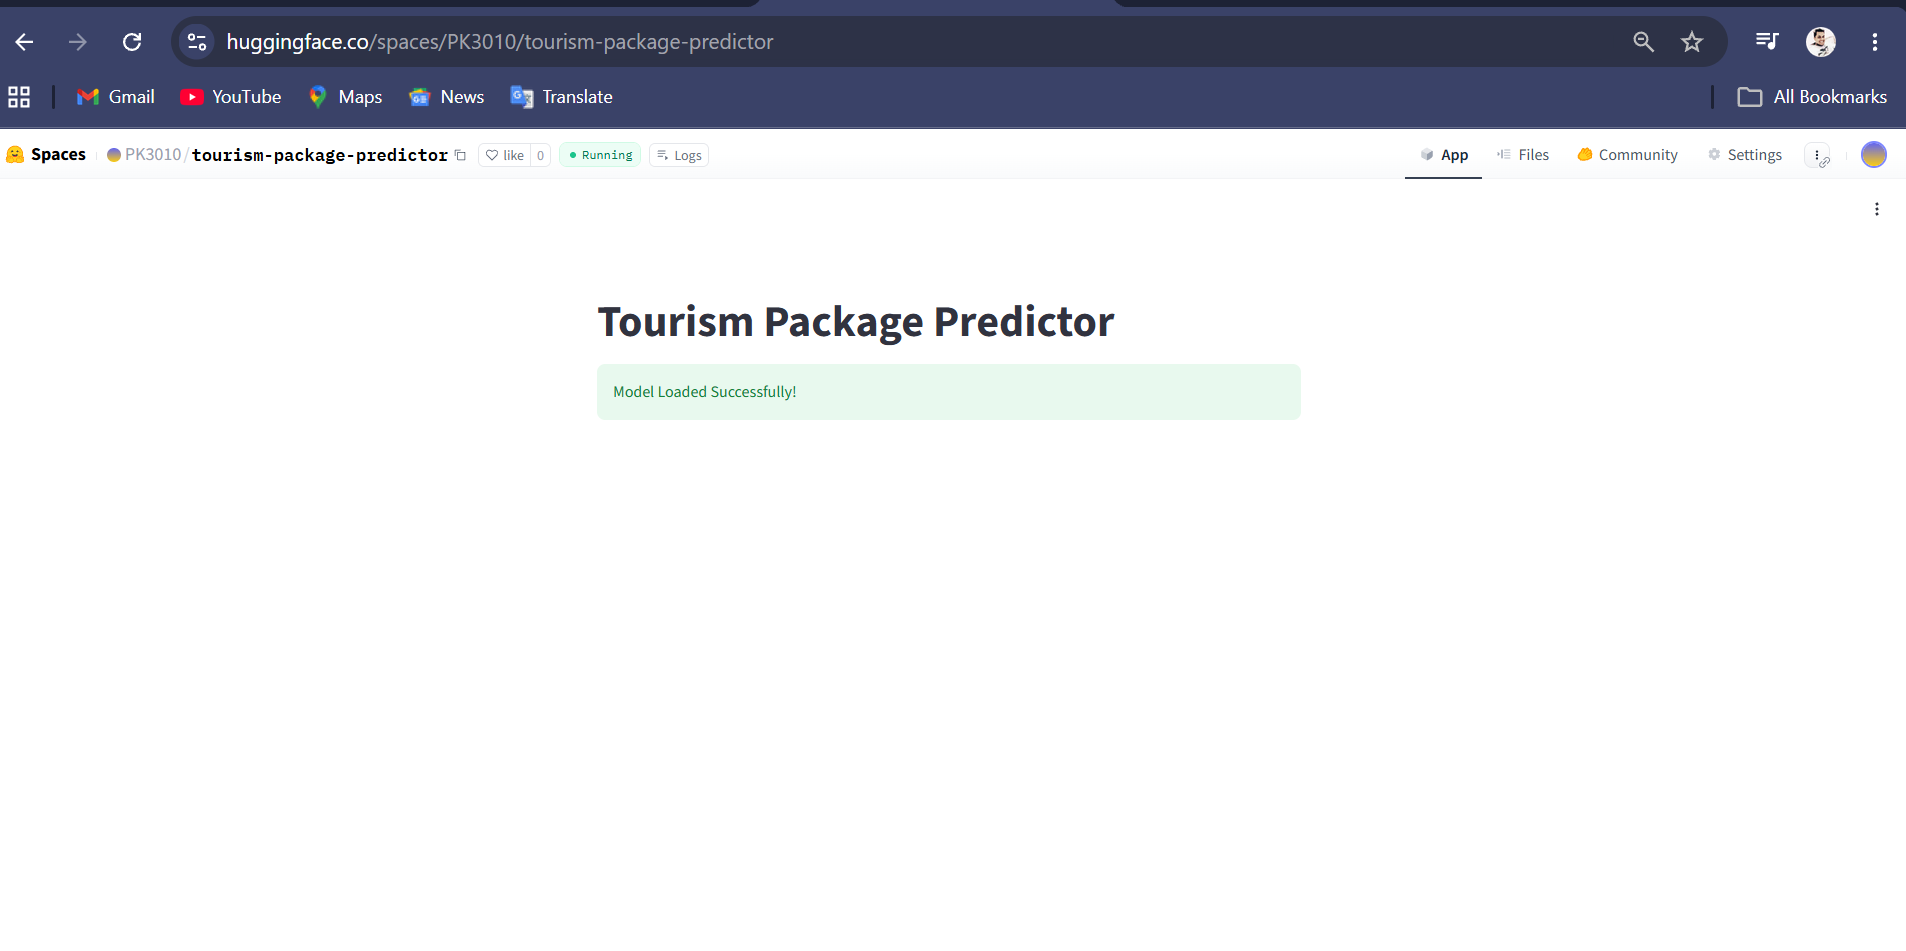


### MLOps Pipeline with Github Actions Workflow